# Probar el modelo con Queries

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicción: Zoro
Confianza: 0.9382608


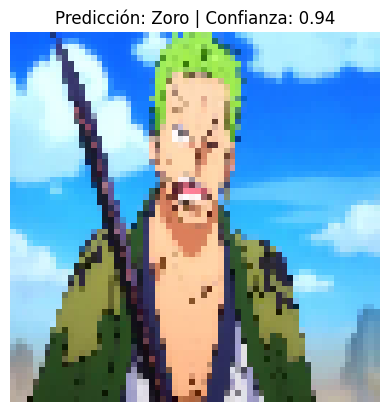

(np.str_('Zoro'), np.float32(0.9382608))

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

class_names = np.load("class_names.npy", allow_pickle=True) #Cargamos los nombres de las clases para la predicción

# Cargar el modelo guardado
model_query = tf.keras.models.load_model("best_model_tl.keras")#Cargamos el modelo que guardamos con el mejor rendimiento para hacer las predicciones

# Función para preparar una imagen nueva
def cargar_imagen_query(image_path, img_size=(64, 64)): 
    img = tf.keras.utils.load_img(image_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array
#Cargamos la imagen que queremos que el modelo haga predicción y la preparamos para que pueda procesarla)

# Función para predecir una imagen 
def predecir_imagen(image_path):
    img, img_array = cargar_imagen_query(image_path)

    predictions = model_query.predict(img_array)#Hacemos la predicción con el modelo cargado utilizando la imagen que preparamos

    predicted_index = np.argmax(predictions[0])#Obtenemos el índice de la clase con la mayor probabilidad
    confidence = np.max(predictions[0])#Obtenemos la confianza de la predicción 

    predicted_class = class_names[predicted_index]#Sacamos el nombre de la clase de la predicción

    print("Predicción:", predicted_class)
    print("Confianza:", confidence)

    plt.imshow(img)
    plt.title(f"Predicción: {predicted_class} | Confianza: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

#La ruta de la imagen que queremos predecir
image_path = "/Users/arturosr/Desktop/OnePiece/OnePieceImage/Imagenes/OnePieceImagnesPrueba/02.png"

predecir_imagen(image_path)